<a href="https://colab.research.google.com/github/SantiaGaGo/Financiero---UniAndes-TodosALaU/blob/main/MODELOSTRADING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 62 kB 1.1 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0


In [ ]:
pip install ta

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for ta: filename=ta-0.10.2-py3-none-any.whl size=29104 sha256=5d8f0887c54e0823aca8c5bddb488888c4c547f6a2ca6ea5c0412aac1b4826bc
  Stored in directory: /root/.cache/pip/wheels/31/31/f1/f2ff471bbc5b84a4b973698ceecdd453ae043971791adc3431
Successfully built ta


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import ta

In [ ]:
df= yfin.download('BTC-USD', start='2016-01-01', end= '2021-01-01')
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,434.334015,36278900
2016-01-02,434.622009,436.062012,431.869995,433.437988,433.437988,30096600
2016-01-03,433.578003,433.743011,424.705994,430.010986,430.010986,39633800
2016-01-04,430.061005,434.516998,429.084015,433.091003,433.091003,38477500
2016-01-05,433.069000,434.182007,429.675995,431.959991,431.959991,34522600
...,...,...,...,...,...,...
2020-12-27,26439.373047,28288.839844,25922.769531,26272.294922,26272.294922,66479895605
2020-12-28,26280.822266,27389.111328,26207.640625,27084.808594,27084.808594,49056742893
2020-12-29,27081.810547,27370.720703,25987.298828,27362.437500,27362.437500,45265946774


In [ ]:
df['EMA_5']=ta.trend.ema_indicator(close=df['Close'], window=5, fillna=True)/df['Close']
df['EMA_20']=ta.trend.ema_indicator(close=df['Close'], window=20, fillna=True)/df['Close']
df['EMA_50']=ta.trend.ema_indicator(close=df['Close'], window=50, fillna=True)/df['Close']
df['EMA_100']=ta.trend.ema_indicator(close=df['Close'], window=100, fillna=True)/df['Close']

#indce de fuerza relativa
df['RSI']= ta.momentum.rsi(close=df['Close'],fillna=True)

#rango verdadero medio
df['ATR']=ta.volatility.average_true_range(high=df['High'], low=df['Low'], close=df['Close'], fillna=True)

#rango de porcentaje de williams
df['WR']= ta.momentum.williams_r(high=df['High'], low=df['Low'], close=df['Close'], fillna=True)

df

,Open,High,Low,Close,Adj Close,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,WR
Date,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,434.334015,36278900,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-21.898866
2016-01-02,434.622009,436.062012,431.869995,433.437988,433.437988,30096600,1.001378,1.001870,1.001986,1.002026,0.000000,0.000000,-32.161470
2016-01-03,433.578003,433.743011,424.705994,430.010986,430.010986,39633800,1.006239,1.008916,1.009581,1.009814,0.000000,0.000000,-54.029560
2016-01-04,430.061005,434.516998,429.084015,433.091003,433.091003,38477500,0.999389,1.001575,1.002307,1.002580,43.782411,0.000000,-27.339657
2016-01-05,433.069000,434.182007,429.675995,431.959991,431.959991,34522600,1.001337,1.003798,1.004738,1.005102,37.320691,0.000000,-37.140447
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-27,26439.373047,28288.839844,25922.769531,26272.294922,26272.294922,66479895605,0.959275,0.857066,0.749519,0.646468,76.670121,1251.880660,-21.739074
2020-12-28,26280.822266,27389.111328,26207.640625,27084.808594,27084.808594,49056742893,0.953665,0.847417,0.737739,0.634460,78.690438,1246.851378,-13.074509
2020-12-29,27081.810547,27370.720703,25987.298828,27362.437500,27362.437500,45265946774,0.962659,0.854169,0.740832,0.635388,79.348515,1256.606413,-10.304209


In [ ]:
cl= np.array(df['Close'])
target=np.where(cl[1:]>cl[:-1], 1, -1)

df.drop(df.tail(1).index, inplace=True)

df['Target']=target
df

,Open,High,Low,Close,Adj Close,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,WR,Target
Date,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,434.334015,36278900,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-21.898866,-1
2016-01-02,434.622009,436.062012,431.869995,433.437988,433.437988,30096600,1.001378,1.001870,1.001986,1.002026,0.000000,0.000000,-32.161470,-1
2016-01-03,433.578003,433.743011,424.705994,430.010986,430.010986,39633800,1.006239,1.008916,1.009581,1.009814,0.000000,0.000000,-54.029560,1
2016-01-04,430.061005,434.516998,429.084015,433.091003,433.091003,38477500,0.999389,1.001575,1.002307,1.002580,43.782411,0.000000,-27.339657,-1
2016-01-05,433.069000,434.182007,429.675995,431.959991,431.959991,34522600,1.001337,1.003798,1.004738,1.005102,37.320691,0.000000,-37.140447,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-26,24677.015625,26718.070312,24522.689453,26437.037109,26437.037109,48332647295,0.933061,0.836774,0.734689,0.635342,78.063543,1166.173764,-3.520070,-1
2020-12-27,26439.373047,28288.839844,25922.769531,26272.294922,26272.294922,66479895605,0.959275,0.857066,0.749519,0.646468,76.670121,1251.880660,-21.739074,1
2020-12-28,26280.822266,27389.111328,26207.640625,27084.808594,27084.808594,49056742893,0.953665,0.847417,0.737739,0.634460,78.690438,1246.851378,-13.074509,1


In [ ]:
df.drop(df.head(29).index, inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,WR,Target
Date,,,,,,,,,,,,,,
2016-01-30,378.864990,380.916992,376.490997,378.255005,378.255005,30284400,1.014102,1.053229,1.094312,1.117589,39.405583,15.224229,-78.595656,-1
2016-01-31,378.292999,380.346985,367.834991,368.766998,368.766998,37894300,1.026796,1.072678,1.117665,1.143446,36.506644,15.030498,-94.457908,1
2016-02-01,369.350006,378.071991,367.957001,373.056000,373.056000,51656700,1.009994,1.054598,1.100705,1.127720,38.701944,14.679390,-87.287464,1
2016-02-02,372.920013,375.882996,372.920013,374.447998,374.447998,40378700,1.004160,1.045851,1.092825,1.121081,39.433863,13.842504,-84.960291,-1
2016-02-03,374.645996,374.950012,368.045013,369.949005,369.949005,45933400,1.010914,1.052992,1.101953,1.132047,37.860379,13.346968,-92.168902,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-26,24677.015625,26718.070312,24522.689453,26437.037109,26437.037109,48332647295,0.933061,0.836774,0.734689,0.635342,78.063543,1166.173764,-3.520070,-1
2020-12-27,26439.373047,28288.839844,25922.769531,26272.294922,26272.294922,66479895605,0.959275,0.857066,0.749519,0.646468,76.670121,1251.880660,-21.739074,1
2020-12-28,26280.822266,27389.111328,26207.640625,27084.808594,27084.808594,49056742893,0.953665,0.847417,0.737739,0.634460,78.690438,1246.851378,-13.074509,1


In [ ]:
x= np.array(df.iloc[:,6:-1])
y= np.array(df['Target'])
print(x.shape)
print(y.shape)

(1797, 7)
(1797,)


In [ ]:
#sckit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_roc_curve
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.1, shuffle=False)
print(x_train.shape)
print(y_train.shape)

(1617, 7)
(1617,)


In [ ]:
ss=StandardScaler()
ss=ss.fit(x_train)

x_train= ss.transform(x_train)
x_test= ss.transform(x_test)

In [ ]:
#support vector machine
svc= SVC()
svc=svc.fit(x_train, y_train)

In [ ]:
svc_pred= svc.predict(x_test)
accuracy_score(y_test, svc_pred)

0.5722222222222222

In [ ]:
confusion_matrix(y_test, svc_pred)

array([[16, 54],
       [23, 87]])

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


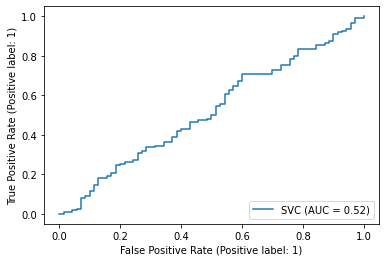

In [ ]:
plot_roc_curve(svc, x_test, y_test)

In [ ]:
#arbol de desicion
dtc= DecisionTreeClassifier()
dtc= dtc.fit(x_train, y_train)

In [ ]:
dtc_pred= dtc.predict(x_test)
accuracy_score(y_test, dtc_pred)

0.5222222222222223

In [ ]:
confusion_matrix(y_test, dtc_pred)

array([[35, 35],
       [51, 59]])

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


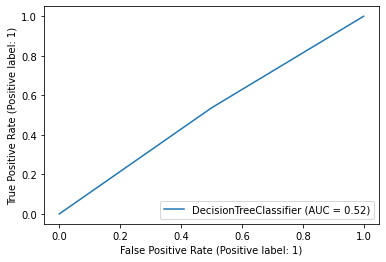

In [ ]:
plot_roc_curve(dtc, x_test, y_test)

In [ ]:
#ramdom forest
rfc=RandomForestClassifier()
rfc= rfc.fit(x_train, y_train)

In [ ]:
rfc_pred= rfc.predict(x_test)
accuracy_score(y_test, rfc_pred)

0.6

In [ ]:
confusion_matrix(y_test, rfc_pred)

array([[54, 16],
       [56, 54]])

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


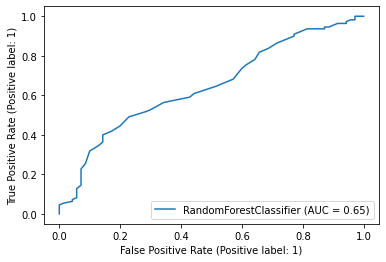

In [ ]:
plot_roc_curve(rfc, x_test, y_test)

In [ ]:
#Redes neuronales
nlp=MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000)
nlp=nlp.fit(x_train, y_train)


In [ ]:
nlp_pred= nlp.predict(x_test)
accuracy_score(y_test, nlp_pred)

0.5111111111111111

In [ ]:
confusion_matrix(y_test, nlp_pred)

array([[41, 29],
       [59, 51]])

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


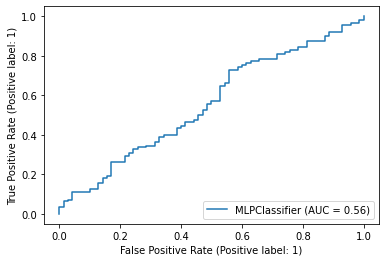

In [ ]:
plot_roc_curve(nlp, x_test, y_test)

In [ ]:

N=len(y_test)
df= df.tail(N)
df['signals'] = rfc_pred
df

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,Open,High,Low,Close,Adj Close,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,WR,Target,signals
Date,,,,,,,,,,,,,,,
2020-07-04,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515,1.000724,1.014542,1.007529,0.972910,44.694897,227.414602,-77.730763,-1,-1
2020-07-05,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143,1.004787,1.019080,1.013479,0.979599,42.980276,224.396986,-86.037010,1,1
2020-07-06,9072.849609,9375.474609,9058.664062,9375.474609,9375.474609,17889263252,0.981647,0.987609,0.981633,0.949122,52.984309,230.997954,-43.256881,-1,-1
2020-07-07,9349.161133,9360.617188,9201.815430,9252.277344,9252.277344,13839652595,0.996479,1.000687,0.994912,0.962517,49.187192,226.902328,-60.735593,1,-1
2020-07-08,9253.020508,9450.335938,9249.500000,9428.333008,9428.333008,19702359883,0.985248,0.983715,0.977262,0.945642,54.234697,225.040443,-4.634044,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-26,24677.015625,26718.070312,24522.689453,26437.037109,26437.037109,48332647295,0.933061,0.836774,0.734689,0.635342,78.063543,1166.173764,-3.520070,-1,-1
2020-12-27,26439.373047,28288.839844,25922.769531,26272.294922,26272.294922,66479895605,0.959275,0.857066,0.749519,0.646468,76.670121,1251.880660,-21.739074,1,-1
2020-12-28,26280.822266,27389.111328,26207.640625,27084.808594,27084.808594,49056742893,0.953665,0.847417,0.737739,0.634460,78.690438,1246.851378,-13.074509,1,1


In [ ]:
#backtesting

equity=[100]

TP=0.03
SL=0.01

pos= 0
for i in range (1,N):
  equity.append(equity[i-1])

  if pos == 1 :
    if df['Close'][i] >= price*(1+TP):
      pos=0
      equity[i]*= (1+TP)

    elif df['Close'][i] <= price*(1-SL):
      pos=0
      equity[i]*= (1-SL)

  elif pos ==-1:

    if df['Close'][i] <= price*(1-TP):
      pos=0
      equity[i]*= (1+TP)

    elif df['Close'][i] >= price*(1+SL):
      pos=0
      equity[i]*= (1-SL)

  else:

    if df['signals'][i] != 0:
      pos =df['signals'][i]
      price= df['Close'][i]

df['equity']= equity

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


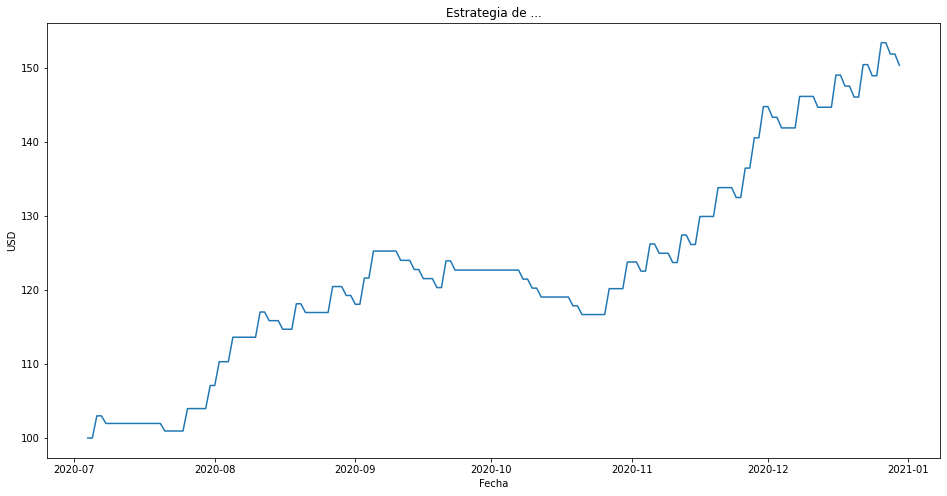

In [ ]:
#visualmente el equity
plt.figure(figsize=(16,8))
plt.plot(df['equity'])
plt.title('Estrategia de ...')
plt.xlabel('Fecha')
plt.ylabel('USD')
plt.show()

In [ ]:
#desempeño de la estrategia
ret =np.log(df['equity']).diff().mean()
ret*=252
#ret

vol=np.log(df['equity']).diff().std()
vol *= np.sqrt(252)

rf=0.01

sharpe_ratio= (ret-rf)/vol
sharpe_ratio

3.1221802501339537

In [ ]:
#portafolio de mercado
df2= yfin.download('^GSPC', start='2020-07-02', end='2020-12-31')
df2

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-07-02,3143.639893,3165.810059,3124.520020,3130.010010,3130.010010,4190830000
2020-07-06,3155.290039,3182.590088,3155.290039,3179.719971,3179.719971,4736450000
2020-07-07,3166.439941,3184.149902,3142.929932,3145.320068,3145.320068,4563700000
2020-07-08,3153.070068,3171.800049,3136.530029,3169.939941,3169.939941,4927700000
2020-07-09,3176.169922,3179.780029,3115.699951,3152.050049,3152.050049,4829020000
...,...,...,...,...,...,...
2020-12-23,3693.419922,3711.239990,3689.280029,3690.010010,3690.010010,3772630000
2020-12-24,3694.030029,3703.820068,3689.320068,3703.060059,3703.060059,1885090000
2020-12-28,3723.030029,3740.510010,3723.030029,3735.360107,3735.360107,3527460000


In [ ]:
#estrategia long
df2['equity']=(100/df2['Close'][0]*df2['Close'])
df2

,Open,High,Low,Close,Adj Close,Volume,equity
Date,,,,,,,
2020-07-02,3143.639893,3165.810059,3124.520020,3130.010010,3130.010010,4190830000,100.000000
2020-07-06,3155.290039,3182.590088,3155.290039,3179.719971,3179.719971,4736450000,101.588173
2020-07-07,3166.439941,3184.149902,3142.929932,3145.320068,3145.320068,4563700000,100.489138
2020-07-08,3153.070068,3171.800049,3136.530029,3169.939941,3169.939941,4927700000,101.275713
2020-07-09,3176.169922,3179.780029,3115.699951,3152.050049,3152.050049,4829020000,100.704152
...,...,...,...,...,...,...,...
2020-12-23,3693.419922,3711.239990,3689.280029,3690.010010,3690.010010,3772630000,117.891317
2020-12-24,3694.030029,3703.820068,3689.320068,3703.060059,3703.060059,1885090000,118.308250
2020-12-28,3723.030029,3740.510010,3723.030029,3735.360107,3735.360107,3527460000,119.340197


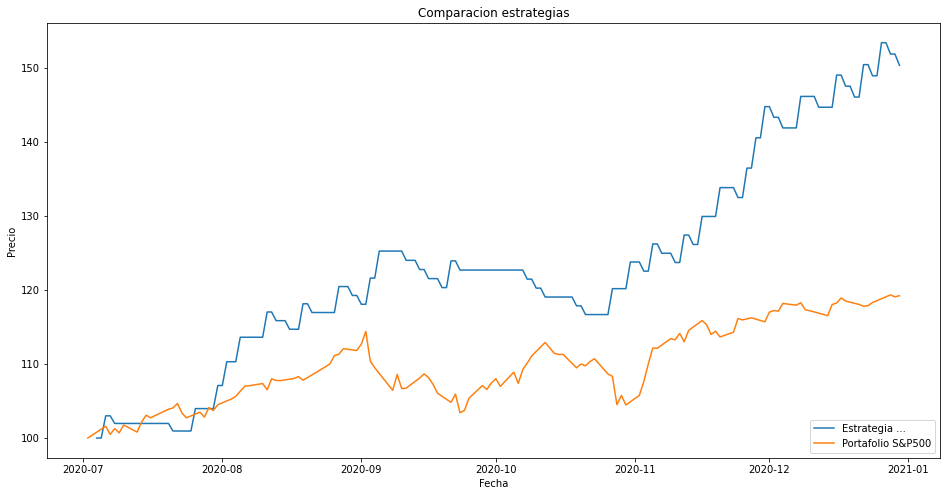

In [ ]:
#comparacion
plt.figure(figsize=(16,8))
plt.plot(df['equity'], label='Estrategia ...')
plt.plot(df2['equity'], label= 'Portafolio S&P500')
plt.title('Comparacion estrategias')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend(loc= 'lower right')
plt.show()

In [ ]:
#desempeño de portafolio de mercado
ret =np.log(df2['equity']).diff().mean()
ret*=252
#ret

vol=np.log(df2['equity']).diff().std()
vol *= np.sqrt(252)

rf=0.01

sharpe_ratio= (ret-rf)/vol
sharpe_ratio

2.056952888305607